In [ ]:
"""
Breast Cancer Prediction with KNN
Author: [Your Name]
Description: Predict whether a breast tumor is malignant or benign using KNN
"""
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
 
# Load the breast cancer dataset
print("Loading breast cancer dataset...")
cancer_data = load_breast_cancer()
 
# The dataset is a Bunch object with 'data', 'target', 'feature_names', etc.
print(f"\nDataset type: {type(cancer_data)}")
print(f"Number of samples: {len(cancer_data.data)}")
print(f"Number of features: {len(cancer_data.feature_names)}")
print(f"Original target classes: {cancer_data.target_names}")
 
# Convert to DataFrame for easier manipulation
df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
df['target'] = 1 - cancer_data.target  # invert labels so 0 = benign, 1 = malignant
df['target'] = df['target'].astype(int)
 
print("\nRelabeled target classes: ['benign', 'malignant']")
 
print("\nFirst few rows:")
print(df.head())
 
print("\nDataset info:")
print(df.info())
 
print("\nTarget distribution:")
print(df['target'].value_counts())
print(f"Benign (0): {(df['target'] == 0).sum()}")
print(f"Malignant (1): {(df['target'] == 1).sum()}")

Loading breast cancer dataset...

Dataset type: <class 'sklearn.utils._bunch.Bunch'>
Number of samples: 569
Number of features: 30
Target classes: ['malignant' 'benign']

First few rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520


BASIC STATISTICS
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.0

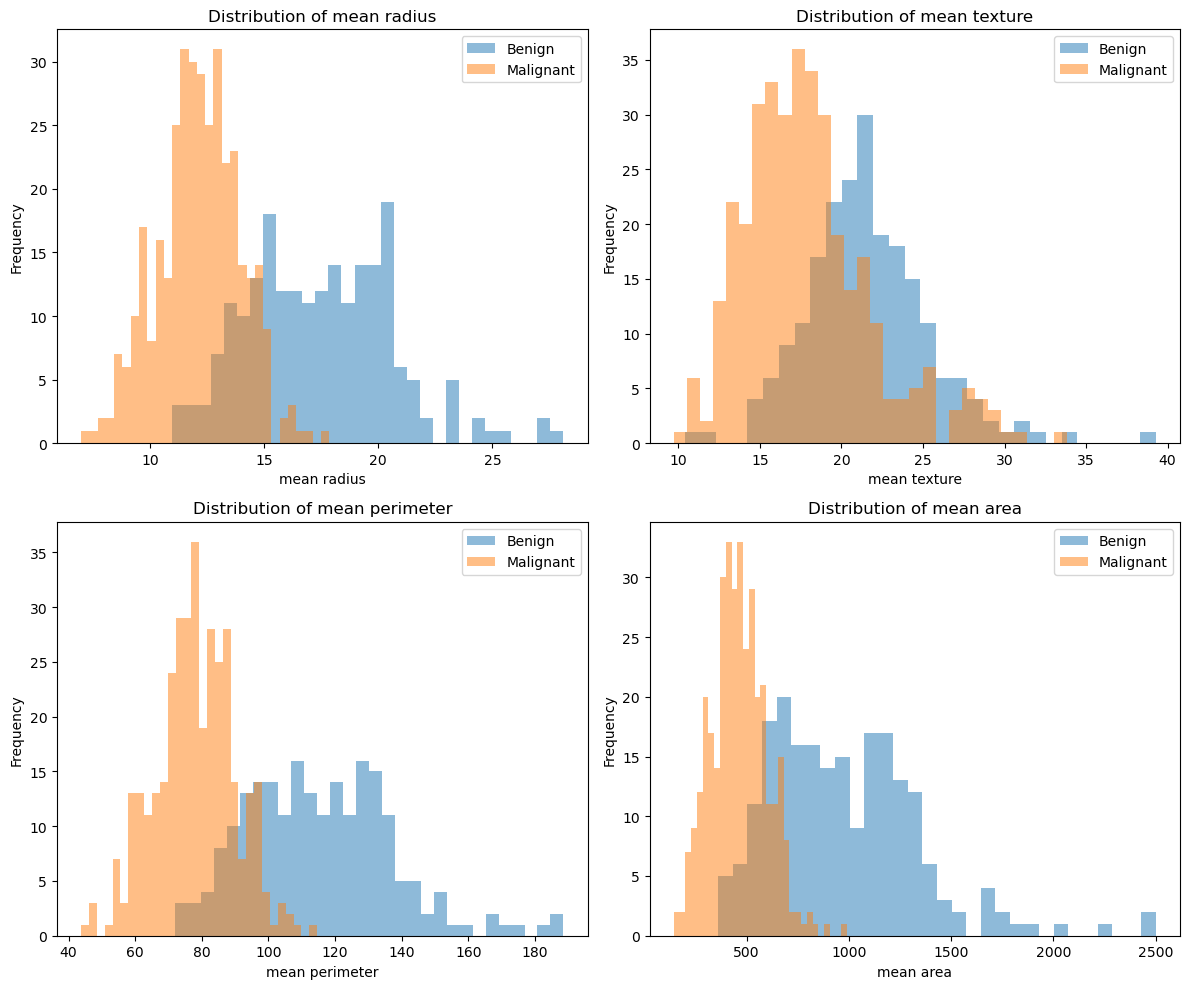

In [ ]:
# Basic statistics
print("\n" + "="*50)
print("BASIC STATISTICS")
print("="*50)
print(df.describe())
 
# Check for missing values
print("\n" + "="*50)
print("MISSING VALUES")
print("="*50)
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✓ No missing values found!")
else:
    print(missing[missing > 0])
 
# Visualize feature distributions (select a few key features)
print("\n" + "="*50)
print("FEATURE DISTRIBUTIONS")
print("="*50)
 
# Select a few representative features to visualize
key_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']
 
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
 
for idx, feature in enumerate(key_features):
    axes[idx].hist(df[df['target'] == 0][feature], alpha=0.5, label='Benign', bins=30)
    axes[idx].hist(df[df['target'] == 1][feature], alpha=0.5, label='Malignant', bins=30)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'Distribution of {feature}')
    axes[idx].legend()
 
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
print("Saved visualization to 'feature_distributions.png'")
plt.show()